In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from src.models.log_reg import train_log_reg
from src.models.metrics import evaluate_model, feature_importance
from src.visualization.plots import (
    plot_roc_curve,
    plot_pr_curve,
    plot_feature_importance,
    plot_confusion_matrix
)

In [4]:
df = pd.read_parquet("../data/processed/traffic_crashes_hourly.parquet")

FEATURES_NUMERIC = [
    "avg_speed",
    "avg_free_flow_speed",
    "avg_congestion",
    "segment_lat",
    "segment_lon",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

FEATURES_CATEGORICAL = [
    "segment_id"
]

FEATURES = FEATURES_NUMERIC + FEATURES_CATEGORICAL

TARGET = "accident"

y = df[TARGET]

TRAIN LOGISTIC REGRESSION MODEL ON NUMERIC FEATURES

log reg convergence [6]

 Logistic Regression Numeric Classification Report
              precision    recall  f1-score   support

           0       0.99      0.58      0.73    415082
           1       0.02      0.65      0.05      6666

    accuracy                           0.58    421748
   macro avg       0.51      0.62      0.39    421748
weighted avg       0.98      0.58      0.72    421748


 Logistic Regression Numeric Metrics
ROC-AUC: 0.6616
PR_AUC: 0.0292
Accuracy: 0.5792
Precision: 0.0243
Recall: 0.6550
F1: 0.0469


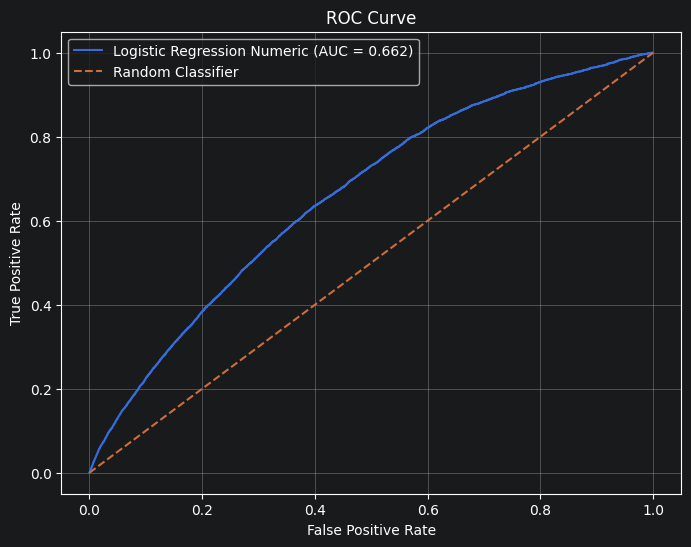

                     feature  importance  abs_importance
6              num__hour_cos   -0.433938        0.433938
5              num__hour_sin   -0.274202        0.274202
2        num__avg_congestion    0.182645        0.182645
4           num__segment_lon    0.133062        0.133062
3           num__segment_lat    0.121908        0.121908
10            num__month_cos   -0.068789        0.068789
1   num__avg_free_flow_speed    0.067172        0.067172
7               num__dow_sin   -0.044773        0.044773
9             num__month_sin   -0.034710        0.034710
0             num__avg_speed   -0.022305        0.022305
8               num__dow_cos    0.006233        0.006233


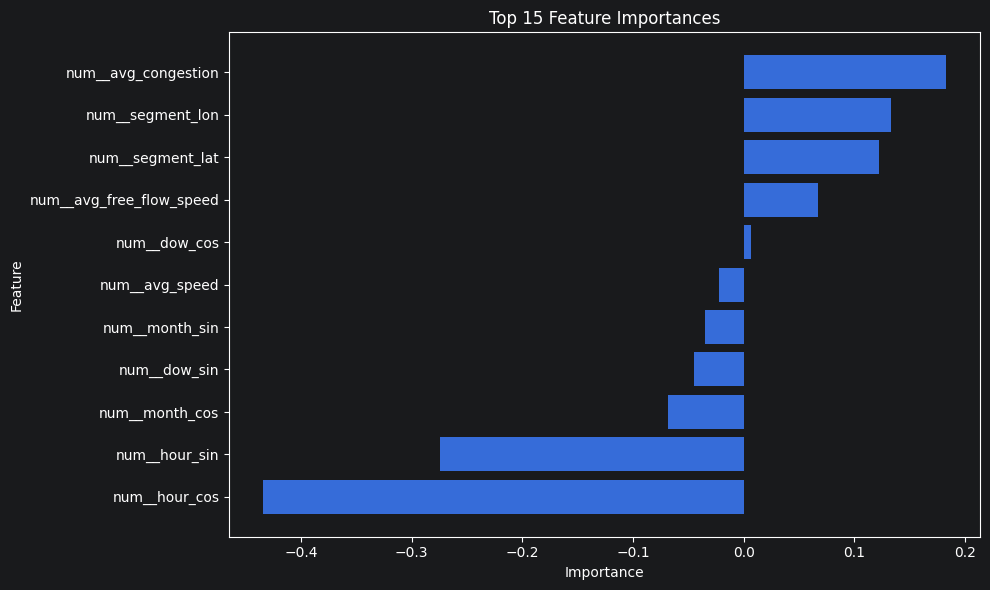

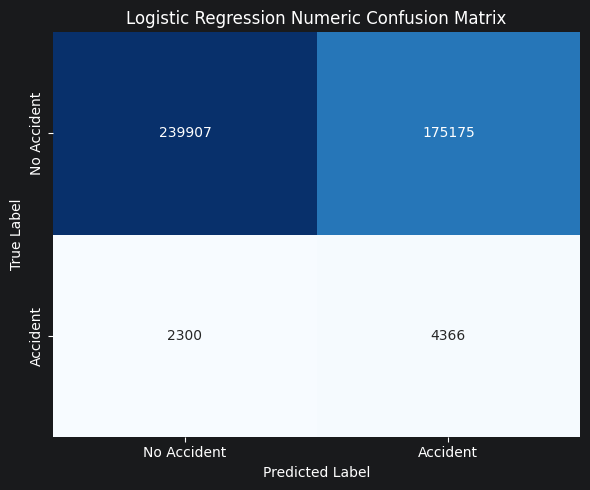

In [5]:
X = df[FEATURES_NUMERIC]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

log_reg_1 = train_log_reg(
    X_train,
    X_test,
    y_train,
    FEATURES_NUMERIC,
)

y_proba_log_reg_1, y_pred_log_reg_1, coefficients_log_reg_1, feature_names_1 = log_reg_1

metrics_log_reg_1 = evaluate_model(
    y_test,
    y_pred_log_reg_1,
    y_proba_log_reg_1,
    "Logistic Regression Numeric",
)

plot_roc_curve(y_test, y_proba_log_reg_1, 'Logistic Regression Numeric', metrics_log_reg_1["ROC-AUC"])
# plot_pr_curve(y_test, y_proba_log_reg, 'Logistic Regression', metrics_log_reg["PR_AUC"])

feature_importance(coefficients_log_reg_1, feature_names_1)

plot_feature_importance(coefficients_log_reg_1, feature_names_1)

plot_confusion_matrix(
    y_test,
    y_pred_log_reg_1,
    "Logistic Regression Numeric"
)

TRAIN LOGISTIC REGRESSION MODEL ON NUMERIC FEATURES + CATEGORICAL FEATURES (SEGMENT_ID)

log reg convergence [128]

 Logistic Regression Numeric + Categorical Classification Report
              precision    recall  f1-score   support

           0       0.99      0.66      0.79    415082
           1       0.03      0.70      0.06      6666

    accuracy                           0.66    421748
   macro avg       0.51      0.68      0.43    421748
weighted avg       0.98      0.66      0.78    421748


 Logistic Regression Numeric + Categorical Metrics
ROC-AUC: 0.7487
PR_AUC: 0.0481
Accuracy: 0.6581
Precision: 0.0320
Recall: 0.7049
F1: 0.0612


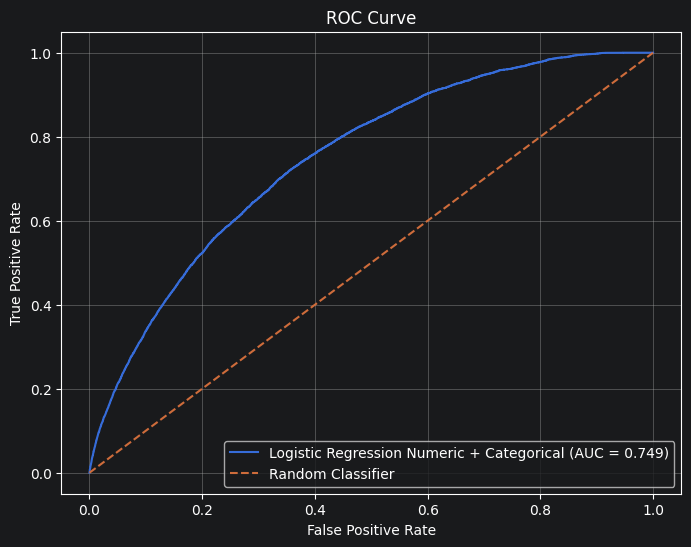

                  feature  importance  abs_importance
784   cat__segment_id_877   -4.586820        4.586820
651   cat__segment_id_700   -4.462079        4.462079
946  cat__segment_id_1192   -4.459544        4.459544
788   cat__segment_id_881   -4.445782        4.445782
787   cat__segment_id_880   -4.392944        4.392944
669   cat__segment_id_719   -4.385216        4.385216
668   cat__segment_id_718   -4.369204        4.369204
870  cat__segment_id_1000   -4.352776        4.352776
667   cat__segment_id_717   -4.343663        4.343663
647   cat__segment_id_696   -4.338390        4.338390
649   cat__segment_id_698   -4.315789        4.315789
650   cat__segment_id_699   -4.315768        4.315768
665   cat__segment_id_715   -4.297939        4.297939
646   cat__segment_id_695   -4.262993        4.262993
666   cat__segment_id_716   -4.246262        4.246262


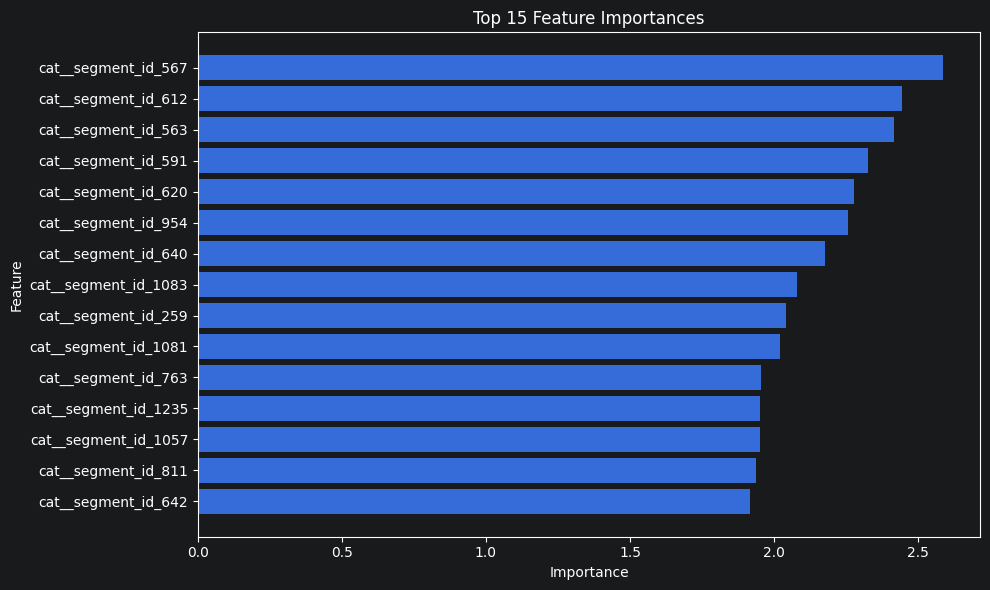

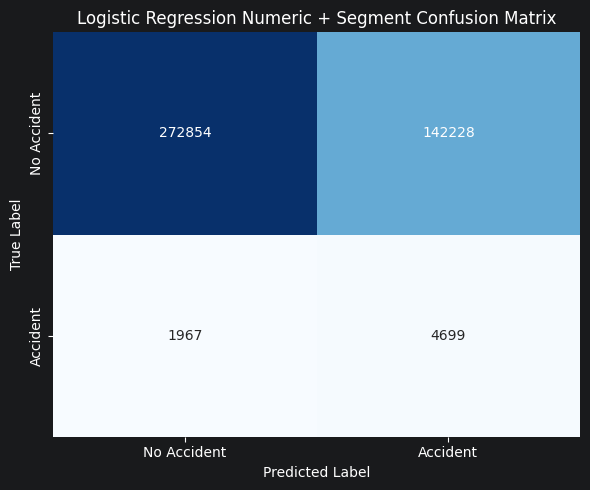

In [6]:
X = df[FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

log_reg_2 = train_log_reg(
    X_train,
    X_test,
    y_train,
    FEATURES_NUMERIC,
    FEATURES_CATEGORICAL,
)

y_proba_log_reg_2, y_pred_log_reg_2, coefficients_log_reg_2, feature_names_2 = log_reg_2

metrics_log_reg_2 = evaluate_model(
    y_test,
    y_pred_log_reg_2,
    y_proba_log_reg_2,
    "Logistic Regression Numeric + Categorical",
)

plot_roc_curve(y_test, y_proba_log_reg_2, 'Logistic Regression Numeric + Categorical', metrics_log_reg_2["ROC-AUC"])
# plot_pr_curve(y_test, y_proba_log_reg, 'Logistic Regression', metrics_log_reg["PR_AUC"])

feature_importance(coefficients_log_reg_2, feature_names_2)

plot_feature_importance(coefficients_log_reg_2, feature_names_2)

plot_confusion_matrix(
    y_test,
    y_pred_log_reg_2,
    "Logistic Regression Numeric + Segment"
)